# Regresión Lineal

**1. Librerias y configuraciones previas**

In [20]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np

# Preprocesado y modelado
# ==============================================================================
from scipy.stats import pearsonr
from scipy import stats
import math

#Separar los datos entrenamiento y prueba
from sklearn.model_selection import train_test_split

#Escalar Variables
from sklearn.preprocessing import MinMaxScaler

#Evaluación del modelo
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import median_absolute_error

#Creación de modelo
import statsmodels.api as sm
#from sklearn.linear_model import LinearRegression

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

**2. Funciones**

In [21]:
# Funciones externas
# ==============================================================================
from utils.funciones import multiple_plot, plot_roc_curve, tidy_corr_matrix, checkVIF

In [22]:
# Función para contruir un modelo de regresión lineal por medio de statsmodels.api

def build_model(X,y):
    
    #A los datos de entrada 'X' se le adiciona una constante
    X = sm.add_constant(X) 
    
    #Se crea y se entrena el modelo de regresion lineal q(statsmodels.api) con 
    #los datos de entrada 'X' y los datos de salida 'y'
    lm = sm.OLS(y,X).fit()
    
    #imprime el resumen del modelo creado
    print(lm.summary()) # model summary
    
    return X

**3. Carga del dataset**

In [23]:
#Se crea un dataframe d con los datos obtenidos de archivo de entrada
d=pd.read_csv('Concrete_Data_Yeh_prep.csv')

In [29]:
# Información sobre tipos de datos y valores no nulos
print("\nInformación general del dataset:")
d.info()


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 807 entries, 0 to 806
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cement                 807 non-null    float64
 1   slag                   807 non-null    float64
 2   flyash                 807 non-null    float64
 3   water                  807 non-null    float64
 4   superplasticizer       807 non-null    float64
 5   coarseaggregate        807 non-null    float64
 6   fineaggregate          807 non-null    float64
 7   age                    807 non-null    int64  
 8   csMPa                  807 non-null    float64
 9   Age_Categoria_Mediana  807 non-null    bool   
 10  Age_Categoria_Vieja    807 non-null    bool   
dtypes: bool(2), float64(8), int64(1)
memory usage: 58.4 KB


In [28]:
# Mostrar las primeras filas
print("Primeras 5 filas del dataset:")
d.head()

Primeras 5 filas del dataset:


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa,Age_Categoria_Mediana,Age_Categoria_Vieja
0,427.5,47.5,0.0,228.0,0.0,932.0,594.0,7,35.08,False,False
1,295.7,0.0,95.6,171.5,8.9,955.1,859.2,56,48.72,True,False
2,296.0,0.0,107.0,221.0,11.0,819.0,778.0,28,31.42,False,False
3,122.6,183.9,0.0,203.5,0.0,958.2,800.1,28,24.29,False,False
4,260.0,101.0,78.0,171.0,10.0,936.0,763.0,28,49.77,False,False


In [27]:
# Dimensiones del dataset
print("\nDimensiones del dataset (filas, columnas):")
print(d.shape)


Dimensiones del dataset (filas, columnas):
(807, 11)


**4. Visualización de datos**

**Variables de entrada:**

In [31]:
# Verificar si hay booleanos
bool_cols = d.select_dtypes(include='bool').columns
print(bool_cols)

Index(['Age_Categoria_Mediana', 'Age_Categoria_Vieja'], dtype='object')


In [32]:
# Convertir booleanos a enteros
d[bool_cols] = d[bool_cols].astype(int)

In [33]:
# Mostrar las primeras filas de las columnas booleanas
d[bool_cols].head()

,Age_Categoria_Mediana,Age_Categoria_Vieja
0,0,0
1,1,0
2,0,0
3,0,0
4,0,0


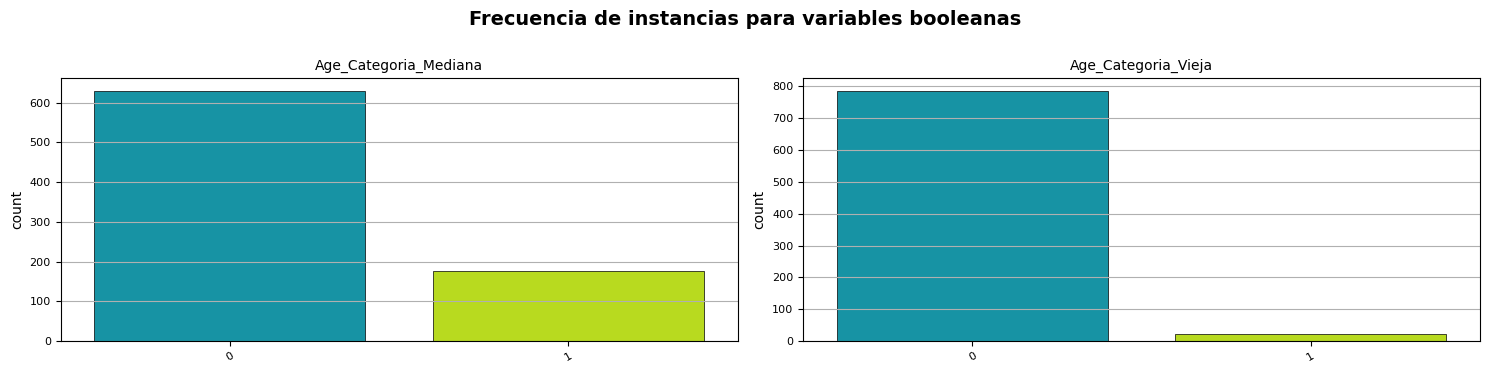

In [45]:
# Visualización de frecuencia de instancias para variables booleanas
multiple_plot(2, d, bool_cols, None, 'countplot', 'Frecuencia de instancias para variables booleanas', 30)

# Ajustar espacio entre título y subgráficas
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

In [47]:
#Lista de variables numéricas

# Nombre de la variable objetivo
target_col = "csMPa"

numCols=d.select_dtypes(include = ['float64','float64','int32','int64']).columns.tolist()

# Eliminar columnas booleanas y la variable de salida
numCols = [col for col in numCols if col not in bool_cols and col != target_col]

d[numCols].head(2)

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age
0,427.5,47.5,0.0,228.0,0.0,932.0,594.0,7
1,295.7,0.0,95.6,171.5,8.9,955.1,859.2,56


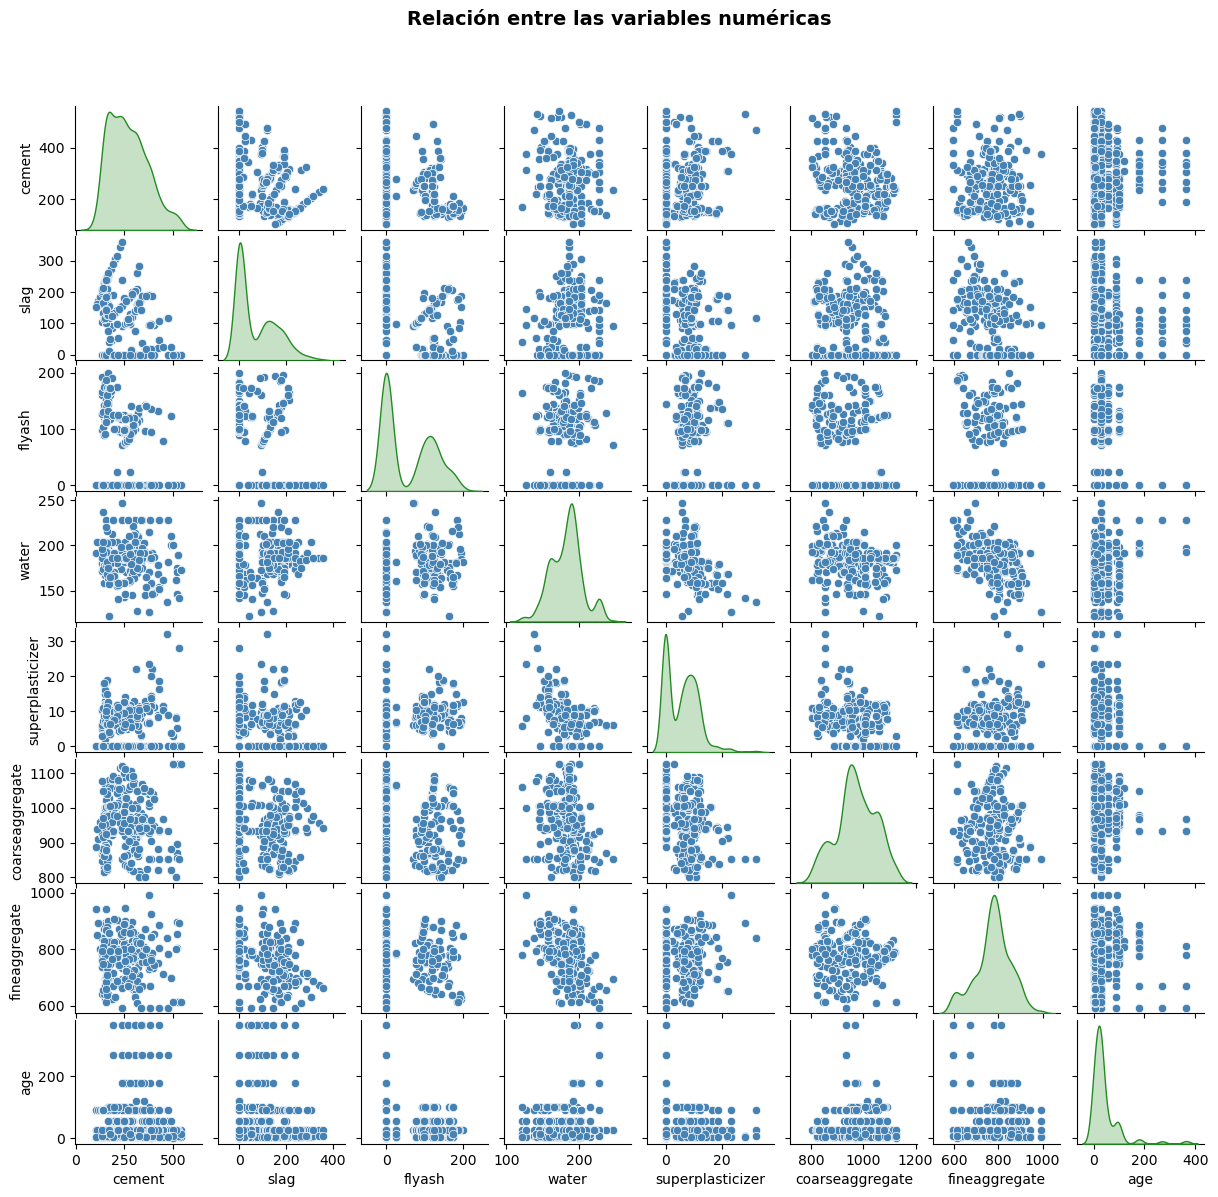

In [50]:
#Visualización de variables numéricas
multiple_plot(1, d , numCols, None, 'scatterplot', 'Relación entre las variables numéricas',30)

**Variable de salida**

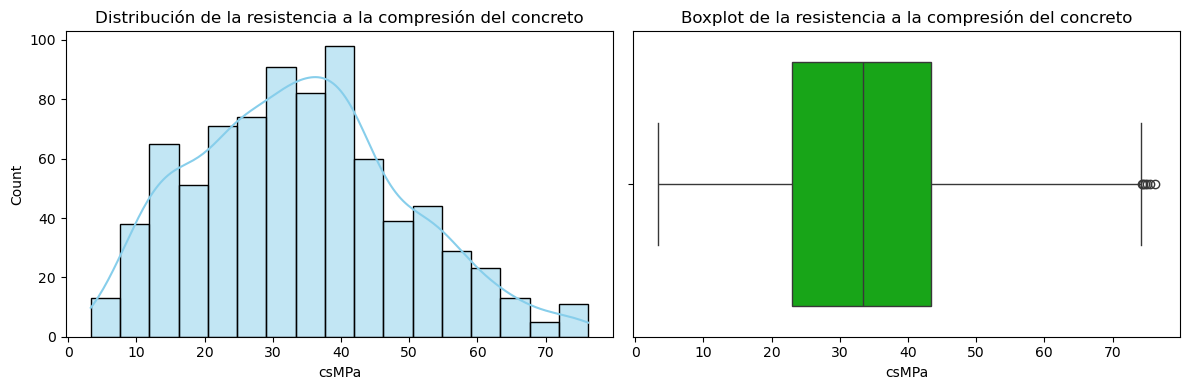

In [52]:
# Visualizar la distribución de la variable de salida

plt.figure(figsize=(12, 4))

# Histograma
plt.subplot(1, 2, 1)
plt.title('Distribución de la resistencia a la compresión del concreto')
sns.histplot(d['csMPa'], kde=True, color='skyblue')

# Boxplot
plt.subplot(1, 2, 2)
plt.title('Boxplot de la resistencia a la compresión del concreto')
sns.boxplot(x=d['csMPa'], palette='nipy_spectral')

plt.tight_layout()
plt.show()

In [53]:
#Descripción de la variable de salida

#Configuración de formato de visualización
pd.set_option('display.float_format', lambda x: '%.0f' % x)

#Descripción
print(d['csMPa'].describe(percentiles = [0.25,0.50,0.75,0.85,0.90,0.95,0.975,1]))

count   807
mean     34
std      15
min       3
25%      23
50%      33
75%      43
85%      51
90%      55
95%      61
97.5%    67
100%     76
max      76
Name: csMPa, dtype: float64


**5. Preparación de datos**

**Transformaciones para la variable de salida**

Se puede observar que la distribución de csMPa (resistencia a compresión):

- La distribución es ligeramente asimétrica a la derecha (positivamente sesgada).
- Sin embargo, no es extremadamente sesgada — se aproxima a una forma algo normal.

- En la gráfica Boxplot hay algunos valores atípicos (outliers) en la parte superior, pero el rango intercuartílico parece razonable.
- La mediana está centrada, lo cual también sugiere una distribución manejable.

Por lo tanto, se decide continuar sin realizar transformaciones.

**Transformaciones a las variables de entrada**

In [54]:
# Tranformaciones X = X^2 a las variables de entrada

varTrans = ['cement','slag','flyash','water','superplasticizer','coarseaggregate','fineaggregate','age']

for elemento in varTrans:
    d[elemento]   = d[elemento] ** 2

**6. Correlaciones**

In [56]:
#Generación de la matriz de correlación
matrizCorr = d[['csMPa']+numCols].corr()

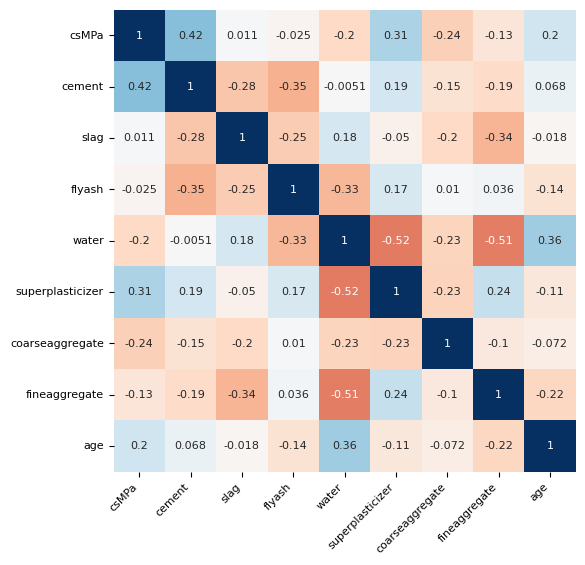

In [57]:
# Mapa de calor (Heatmap) de la matriz de correlaciones

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))

sns.heatmap(
    matrizCorr,
    annot     = True,
    cbar      = False,
    annot_kws = {"size": 8},
    vmin      = -1,
    vmax      = 1,
    center    = 0,
    cmap      = 'RdBu', #sns.diverging_palette(20, 220, n=200),
    square    = True,
    ax        = ax
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation = 45,
    horizontalalignment = 'right',
)


ax.tick_params(labelsize = 8)


In [60]:
# Convertir a formato largo (tidy)
df_corr = matrizCorr.stack().reset_index()
df_corr.columns = ['variable_1', 'variable_2', 'r']

# Quitar duplicados y autocomparaciones
df_corr = df_corr[df_corr['variable_1'] != df_corr['variable_2']]

# Agregar columna de valor absoluto de r
df_corr['abs_r'] = df_corr['r'].abs()

# Filtrar correlaciones con la variable objetivo
df_filtrado = df_corr[df_corr['variable_2'] == 'csMPa']

# Mostrar las fuertes
df_filtrado[df_filtrado['abs_r'] >= 0.5]


,variable_1,variable_2,r,abs_r


**4. Creación del modelo**

**Dividir el conjunto de datos**

In [12]:
#Se establece la variable de entrada 'X' y la variable de salida 'y'

X = df[[
    'Cement (component 1)',
    'Blast Furnace Slag (component 2)',
    'Fly Ash (component 3)',
    'Water (component 4)',
    'Superplasticizer (component 5)',
    'Coarse Aggregate (component 6)',
    'Fine Aggregate (component 7)',
    'Age'
]]

y = df['Concrete compressive strength']

KeyError: "None of [Index(['Engine'], dtype='object')] are in the [columns]"